Installs

# Reinforcement Learning: Learning to Play a Game

Iman Mossavat

Fontys ICT

September 2026

Today we are going to look at a different way of teaching a computer to make decisions, in this case, how to play an **Atari game**.

Instead of telling the computer exactly how to play the game, we give it a **game environment**, let it take actions, and give it feedback about what happened.

The computer can then gradually learn which actions tend to lead to better outcomes.

This is called **Reinforcement Learning**, or **RL**.

We are going to use a classic Atari game called **Breakout** as our example.

The goal today is to understand the basic idea of reinforcement learning and see what a trained RL agent actually looks like when it is playing a game.

For this exercise, we are giving you **models that have already been trained**. Normally, when you work on your own reinforcement learning problem, you will have to train your own model.

Atari games are useful for learning because they are **well-known benchmark problems**. Researchers have been using these games for many years, so pretrained agents and established environments are available for us to experiment with.

This means that we can focus today on understanding **what reinforcement learning is and how an RL agent interacts with an environment**, rather than waiting hours for a model to learn how to play.

And the ecosystem is:

Gymnasium → provides the environment

Stable-Baselines3 → provides the RL algorithm

DQN → the trained agent/model

Atari/ALE → provides the game

Hugging Face → provides the pretrained model


In [30]:
!pip install -q "shimmy>=2.0"

In [ ]:
!pip install -q "stable-baselines3[extra]" "gymnasium[atari]" "ale-py" huggingface_sb3

In Reinforcement Learning, a computer learns by interacting with an environment.

The computer is the agent. It observes the game, takes an action, and receives feedback about what happened.

For example:

Agent → Action → Environment → Feedback → Agent → ...

By repeating this process, the agent can learn which actions tend to produce better results.

# Task 1: Explore the RL Agent

Look at the code below.

You **do not need to understand everything**.

For now, ignore:

* `AtariWrapper`
* `DummyVecEnv`
* `VecFrameStack`
* the details of DQN
* the `custom_objects` settings

Focus on the parts that show how the **agent interacts with the environment**.

While reading the code, try to find:

* Where is the **environment** created?
* Where is the **trained model** loaded?
* Where does the agent **observe** the game?
* Where does the agent **choose an action**?
* Where does the environment give the agent **feedback**?
* Where does the loop repeat?

Then answer the questions below the code.


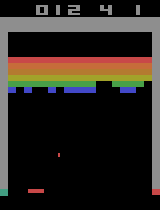

Step: 449
Action: 1
Reward: 0.0
Total reward: 2.0


KeyboardInterrupt: 

In [31]:
# ============================================================
# 1. THE RL ECOSYSTEM
# ============================================================

# Gymnasium:
# Provides the ENVIRONMENT that the agent interacts with.
import gymnasium as gym

# Stable-Baselines3:
# Provides ready-to-use implementations of RL algorithms.
# We are using DQN (Deep Q-Network).
from stable_baselines3 import DQN

# AtariWrapper:
# Prepares the Atari game in the same way the agent expects.
from stable_baselines3.common.atari_wrappers import AtariWrapper

# DummyVecEnv and VecFrameStack:
# You can ignore these for now.
# They prepare the game data in the format
# expected by the pretrained model.
#
# VecFrameStack also gives the model the last 4 frames,
# instead of only the current frame.
from stable_baselines3.common.vec_env import (
    DummyVecEnv,
    VecFrameStack
)

# ============================================================
# 2. CREATE THE ENVIRONMENT
# ============================================================

# Gymnasium gives us the Atari Breakout environment.
#
# The ENVIRONMENT is the game.
# It knows:
#   - what the game looks like
#   - which actions are possible
#   - what happens after an action
#   - what reward the agent receives
def make_breakout():

    env = gym.make(
        "BreakoutNoFrameskip-v4",
        render_mode="rgb_array"
    )

    # Apply the standard Atari preprocessing.
    env = AtariWrapper(env)

    return env


# Stable-Baselines3 works with vectorized environments.
# We only have ONE game, so there is one environment here.
env = DummyVecEnv([make_breakout])


# The agent receives 4 consecutive frames.
#
# Why?
# A single image does not tell us how the ball is moving.
# Looking at several frames gives the agent information about
# movement and direction.
env = VecFrameStack(env, n_stack=4)


# ============================================================
# 3. LOAD THE PRETRAINED AGENT
# ============================================================

# We are NOT training a model here.
#
# This model has already been trained.
#
# Hugging Face provided the pretrained model file, and
# Stable-Baselines3 knows how to load and use the DQN.
model = DQN.load(
    checkpoint,
    env=env,
    custom_objects={
        # Compatibility settings for this older pretrained model.
        "optimize_memory_usage": False,
        "handle_timeout_termination": False,
    }
)

print("Pretrained agent loaded!")


# ============================================================
# 4. THE REINFORCEMENT LEARNING LOOP
# ============================================================

from IPython.display import display, clear_output
from PIL import Image
import time

# Start a new game.
#
# The environment gives us the first OBSERVATION.
obs = env.reset()

total_reward = 0


# The agent now repeatedly interacts with the environment.
for step in range(5000):

    # --------------------------------------------------------
    # OBSERVE → ACT
    # --------------------------------------------------------
    #
    # The agent looks at the current observation
    # and chooses an ACTION.
    #
    # For example:
    #   0 = do something
    #   1 = move left
    #   2 = move right
    #
    # The exact action numbers depend on the Atari environment.
    action, _ = model.predict(
        obs,
        deterministic=True
    )


    # --------------------------------------------------------
    # ACT → ENVIRONMENT
    # --------------------------------------------------------
    #
    # We send the action to the game.
    #
    # The environment then:
    #   1. changes the game
    #   2. gives us a new observation
    #   3. gives us a reward
    #   4. tells us whether the game is finished
    obs, reward, done, info = env.step(action)


    # Add the reward to our running total.
    total_reward += reward[0]


    # --------------------------------------------------------
    # OBSERVE THE RESULT
    # --------------------------------------------------------

    frame = env.render()

    clear_output(wait=True)
    display(Image.fromarray(frame))

    print("Step:", step)
    print("Action:", action[0])
    print("Reward:", reward[0])
    print("Total reward:", total_reward)


    # Slow the display down so humans can watch it.
    time.sleep(0.03)


    # --------------------------------------------------------
    # GAME OVER?
    # --------------------------------------------------------

    if done[0]:
        print("Game over. Starting a new game...")

        time.sleep(1)

        # Start the RL loop again with a fresh game.
        obs = env.reset()
        total_reward = 0

# Investigate the Agent with Python

Do not just answer the questions by reading the code.

Use **Python `print()` statements** to investigate what is happening.

Think of it as asking the program questions.

For example:

```python
print(type(env))
print(env.observation_space)
print(env.action_space)
```

You can also print variables:

```python
print(obs)
print(action)
print(reward)
```

You do not need to understand everything that Python prints. Look at the output and use it to help you answer the questions.

### Why are we doing this?

Writing small pieces of code and immediately seeing the result is one of the easiest ways to learn Python.

You are not trying to build a large program yet.

You are simply learning to **inspect what is happening inside a program**.

Try something, run it, look at the result, and change it.

## Questions

Use `print()` statements and the code to investigate:

1. What is the name of the game environment?

2. What does `env` represent?

3. What is the model used for?

4. What does `obs` represent?

5. What does `action` represent?

6. What does `reward` represent?

7. Find this line:

```python
action, _ = model.predict(obs)
```

In your own words, what is happening here?

Try printing `action` to see what the model actually produces.

8. Find this line:

```python
obs, reward, done, info = env.step(action)
```

What happens after the agent takes an action?

Try printing `reward` and `done`.

9. Find the three parts of this loop:

**Observe → Act → Receive feedback**

Which lines of code correspond to each part?

10. Why do you think the agent needs to repeat this process many times?


# Lunar Lander



In [41]:
!pip install -q "gymnasium[box2d]" stable-baselines3 huggingface_sb3 rl_zoo3

In [45]:
import gymnasium as gym

from stable_baselines3 import A2C
from huggingface_sb3 import load_from_hub


# ============================================================
# 1. CREATE THE ENVIRONMENT
# ============================================================



env = gym.make(
    "LunarLander-v3",
    render_mode="rgb_array"
)
# ============================================================
# 2. DOWNLOAD THE PRETRAINED MODEL
# ============================================================

checkpoint = load_from_hub(
    repo_id="sb3/a2c-LunarLander-v3",
    filename="a2c-LunarLander-v3.zip"
)


# ============================================================
# 3. LOAD THE PRETRAINED AGENT
# ============================================================

model = A2C.load(
    checkpoint,
    env=env
)

print("Pretrained agent loaded!")

Pretrained agent loaded!


In [47]:
# ============================================================
# 1. CREATE THE LUNARLANDER ENVIRONMENT
# ============================================================

import gymnasium as gym

env = gym.make(
    "LunarLander-v3",
    render_mode="rgb_array"
)


# ============================================================
# 2. LOAD THE PRETRAINED AGENT
# ============================================================

from stable_baselines3 import A2C

model = A2C.load(
    checkpoint,
    env=env
)

print("Pretrained agent loaded!")


# ============================================================
# 3. THE REINFORCEMENT LEARNING LOOP
# ============================================================

from IPython.display import display, clear_output
from PIL import Image
import time

# Start a new game.
obs, info = env.reset()

total_reward = 0


for step in range(2000):

    # --------------------------------------------------------
    # OBSERVE → ACT
    # --------------------------------------------------------
    #
    # The agent looks at the current observation
    # and chooses an action.
    action, _ = model.predict(
        obs,
        deterministic=True
    )


    # --------------------------------------------------------
    # ACT → ENVIRONMENT
    # --------------------------------------------------------
    #
    # Send the action to the game.
    obs, reward, terminated, truncated, info = env.step(action)

    total_reward += reward


    # --------------------------------------------------------
    # SHOW THE GAME
    # --------------------------------------------------------

    frame = env.render()

    clear_output(wait=True)
    display(Image.fromarray(frame))

    print("Step:", step)
    print("Action:", action)
    print("Reward:", reward)
    print("Total reward:", total_reward)


    # Slow it down so humans can watch.
    time.sleep(0.03)


    # --------------------------------------------------------
    # GAME OVER?
    # --------------------------------------------------------

    if terminated or truncated:

        print("Game over. Starting a new game...")

        time.sleep(1)

        obs, info = env.reset()
        total_reward = 0

KeyboardInterrupt: 

# Task: Explore the Environment and Build a Random Agent

Now it is your turn to investigate the environment.

We are using **Gymnasium**, from the Farama Foundation, to provide the game environment.

Take a look at the Gymnasium documentation and find out what an environment does.

[Gymnasium documentation](https://gymnasium.farama.org/?utm_source=chatgpt.com)

You do not need to understand everything in the documentation. Focus on the basic idea of an **environment**, its **observations**, its **actions**, and its **rewards**.

## 1. Explore the environment

Use Python to investigate our LunarLander environment.

Try printing:

```python
print(env)
print(env.observation_space)
print(env.action_space)
```

Also try:

```python
obs, info = env.reset()

print(obs)
print(obs.shape)
```

Think about:

* What does the environment represent?
* What does the agent observe?
* What actions are possible?

## 2. Make your own agent

So far, we have used a trained model to choose the actions.

Now remove the trained model from the decision-making process.

Instead, let Python choose a **random action**.

First find out how many actions are possible:

```python
print(env.action_space.n)
```

Then create a loop that:

1. Starts the game
2. Chooses a random action
3. Sends the action to the environment
4. Receives the new observation and reward
5. Repeats this many times

You can use Python's `random` module:

```python
import random
```

Your goal is to write the loop yourself.

### 3. Watch what happens

Run your random agent and watch the LunarLander.

Does it land successfully?

Does it behave differently each time?

What happens to the reward?

### Think about it

Our trained agent does:

**Observation → Model → Action → Environment → Reward**

Your random agent does:

**Observation → Random choice → Action → Environment → Reward**

The environment is exactly the same.

The only thing we changed is **how the action is chosen**.

Why do you think a trained agent can do better than an agent that simply chooses random actions?


# Challenge:
Today you saw mostly how a trained model performs, can you train your own model to play Snake?